# Model-Free Tabular Reinforcement Learning: Method Comparison

This notebook connects the four tabular model-free methods developed in the previous notebooks: Monte Carlo Prediction, TD(0), SARSA, and Q-Learning.

Its purpose is **comparison and synthesis**, not to repeat the full algorithms, training loops, or simulations that were already demonstrated in detail.

## 1. Objective

The objective is to show how model-free tabular reinforcement learning progresses from **prediction** to **control**, and exactly what changes in the learning target from one method to the next.

The two earlier notebooks already demonstrate the algorithms step by step:

- **Blackjack:** Monte Carlo Prediction and TD(0)
- **CliffWalking:** SARSA and Q-Learning

This notebook focuses on four questions:

1. What does each method learn?
2. What target does each method use?
3. Does it bootstrap or wait for the complete episode?
4. Is it prediction, on-policy control, or off-policy control?

No new environment or separate simulation is introduced here because that would repeat the previous notebooks.

## 2. Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

## 3. The Main Progression

The progression can be understood through three changes.

### Monte Carlo → TD(0)

Both methods perform **state-value prediction** under a fixed policy, but the learning target changes from the complete sampled return to a one-step bootstrapped target.

```text
Monte Carlo
complete return G_t
        ↓
TD(0)
R_t+1 + γV(S_t+1)
```

### TD(0) → SARSA

The problem changes from **prediction** to **control**. Instead of learning only $V(s)$, SARSA learns $Q(s,a)$ so that actions can be selected.

```text
TD(0)
learn V(s)
        ↓
SARSA
learn Q(s,a)
```

### SARSA → Q-Learning

Both methods learn $Q(s,a)$, but the next-state target changes. SARSA uses the action actually selected by the current behavior policy, while Q-Learning uses the largest next-state action value.

```text
SARSA
Q(S_t+1,A_t+1)
        ↓
Q-Learning
max_a Q(S_t+1,a)
```

## 4. One Common Update Pattern

Although the four methods use different targets, their tabular updates can be viewed through one common pattern:

$$\text{new estimate}=\text{old estimate}+\alpha\left[\text{target}-\text{old estimate}\right].$$

What changes is the **target**.

### Monte Carlo

$$Y_t^{MC}=G_t$$

### TD(0)

$$Y_t^{TD}=R_{t+1}+\gamma V(S_{t+1})$$

### SARSA

$$Y_t^{SARSA}=R_{t+1}+\gamma Q(S_{t+1},A_{t+1})$$

### Q-Learning

$$Y_t^{Q}=R_{t+1}+\gamma\max_aQ(S_{t+1},a)$$

## 5. Side-by-Side Comparison

The table below summarizes the role of each method without repeating its full pseudocode.

In [2]:
methods = [
    {
        "Method": "Monte Carlo",
        "Learns": "Vπ(s)",
        "Target": "G_t",
        "Waits for terminal?": "Yes",
        "Bootstraps?": "No",
        "Role": "Prediction",
        "Policy relation": "Fixed policy",
    },
    {
        "Method": "TD(0)",
        "Learns": "Vπ(s)",
        "Target": "R + γV(s')",
        "Waits for terminal?": "No",
        "Bootstraps?": "Yes",
        "Role": "Prediction",
        "Policy relation": "Fixed policy",
    },
    {
        "Method": "SARSA",
        "Learns": "Q(s,a)",
        "Target": "R + γQ(s',a')",
        "Waits for terminal?": "No",
        "Bootstraps?": "Yes",
        "Role": "Control",
        "Policy relation": "On-policy",
    },
    {
        "Method": "Q-Learning",
        "Learns": "Q(s,a)",
        "Target": "R + γ max Q(s',a)",
        "Waits for terminal?": "No",
        "Bootstraps?": "Yes",
        "Role": "Control",
        "Policy relation": "Off-policy",
    },
]

headers = list(methods[0].keys())

lines = [
    "| " + " | ".join(headers) + " |",
    "|" + "|".join(["---"] * len(headers)) + "|",
]

for row in methods:
    lines.append(
        "| " + " | ".join(str(row[h]) for h in headers) + " |"
    )

display(Markdown("\n".join(lines)))

| Method | Learns | Target | Waits for terminal? | Bootstraps? | Role | Policy relation |
|---|---|---|---|---|---|---|
| Monte Carlo | Vπ(s) | G_t | Yes | No | Prediction | Fixed policy |
| TD(0) | Vπ(s) | R + γV(s') | No | Yes | Prediction | Fixed policy |
| SARSA | Q(s,a) | R + γQ(s',a') | No | Yes | Control | On-policy |
| Q-Learning | Q(s,a) | R + γ max Q(s',a) | No | Yes | Control | Off-policy |

## 6. Comparison as a Visual Matrix

The following matrix is not a performance score. It is a compact visual summary of the structural properties of the four methods.

`1` means the property applies; `0` means it does not.

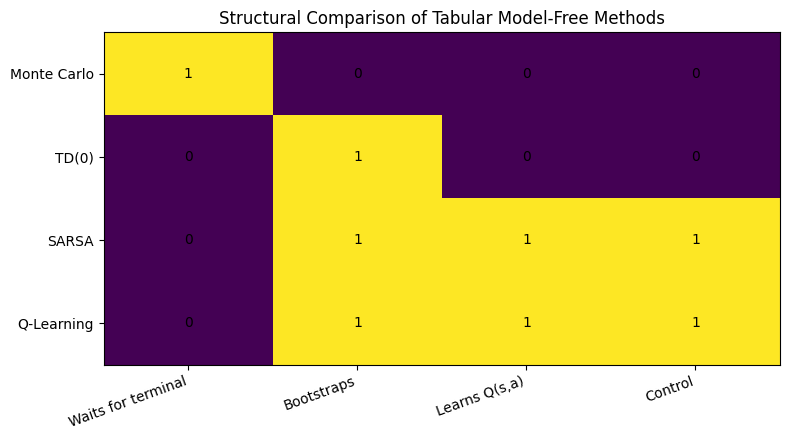

In [3]:
method_names = ["Monte Carlo", "TD(0)", "SARSA", "Q-Learning"]
property_names = [
    "Waits for terminal",
    "Bootstraps",
    "Learns Q(s,a)",
    "Control",
]

property_matrix = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 1, 1, 1],
    [0, 1, 1, 1],
])

plt.figure(figsize=(8, 4.5))
plt.imshow(property_matrix, aspect="auto")

plt.xticks(
    np.arange(len(property_names)),
    property_names,
    rotation=20,
    ha="right",
)
plt.yticks(
    np.arange(len(method_names)),
    method_names,
)

for row in range(property_matrix.shape[0]):
    for col in range(property_matrix.shape[1]):
        plt.text(
            col,
            row,
            str(property_matrix[row, col]),
            ha="center",
            va="center",
        )

plt.title("Structural Comparison of Tabular Model-Free Methods")
plt.tight_layout()
plt.show()

## 7. Numerical Target Comparison

A small numerical example is useful for seeing how the target itself changes. These values are **illustrative only**; they are not benchmark-performance results.

Use

$$\alpha=0.1,\qquad\gamma=0.9.$$

For prediction, let the current estimate be $V(S_t)=0.30$, the complete Monte Carlo return be $G_t=1.00$, and the next-state value be $V(S_{t+1})=0.50$.

For control, let $Q(S_t,A_t)=0.30$, let SARSA's actual next action have value $0.20$, and let the largest next-state action value be $0.50$.

In [4]:
alpha = 0.1
gamma = 0.9
reward = 0.0

# Monte Carlo
value_old = 0.30
mc_target = 1.00
mc_error = mc_target - value_old
mc_new = value_old + alpha * mc_error

# TD(0)
v_next = 0.50
td_target = reward + gamma * v_next
td_error = td_target - value_old
td_new = value_old + alpha * td_error

# SARSA
q_old = 0.30
actual_next_q = 0.20
sarsa_target = reward + gamma * actual_next_q
sarsa_error = sarsa_target - q_old
sarsa_new = q_old + alpha * sarsa_error

# Q-Learning
next_q_values = np.array([0.20, 0.50, 0.40, 0.10])
best_next_q = np.max(next_q_values)
q_target = reward + gamma * best_next_q
q_error = q_target - q_old
q_new = q_old + alpha * q_error

comparison_rows = [
    ("Monte Carlo", mc_target, mc_error, mc_new),
    ("TD(0)", td_target, td_error, td_new),
    ("SARSA", sarsa_target, sarsa_error, sarsa_new),
    ("Q-Learning", q_target, q_error, q_new),
]

print(f"{'Method':<15}{'Target':>12}{'Error':>12}{'New estimate':>16}")
for method, target, error, new_estimate in comparison_rows:
    print(
        f"{method:<15}"
        f"{target:>12.3f}"
        f"{error:>12.3f}"
        f"{new_estimate:>16.3f}"
    )

Method               Target       Error    New estimate
Monte Carlo           1.000       0.700           0.370
TD(0)                 0.450       0.150           0.315
SARSA                 0.180      -0.120           0.288
Q-Learning            0.450       0.150           0.315


### Illustrative Target Values

The graph below visualizes only the **target values produced by the shared numerical example**. It should not be interpreted as one algorithm performing better than another.

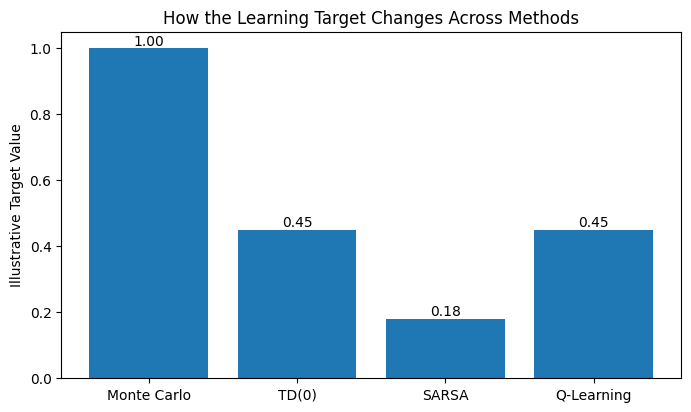

In [5]:
target_names = ["Monte Carlo", "TD(0)", "SARSA", "Q-Learning"]
target_values = [mc_target, td_target, sarsa_target, q_target]

plt.figure(figsize=(8, 4.5))
bars = plt.bar(target_names, target_values)

plt.ylabel("Illustrative Target Value")
plt.title("How the Learning Target Changes Across Methods")

for bar, value in zip(bars, target_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom",
    )

plt.show()

## 8. Prediction vs. Control

The first two methods answer a **prediction** question:

> How valuable is state $s$ if the current policy continues to be followed?

They estimate

$$V^\pi(s).$$

The next two methods answer a **control** question:

> Which action should be selected in state $s$?

They learn

$$Q(s,a)$$

and obtain a greedy policy from

$$\pi(s)=\arg\max_aQ(s,a).$$

This is the key conceptual transition from evaluating a policy to improving decision-making.

## 9. On-Policy vs. Off-Policy Control

SARSA and Q-Learning differ most clearly in how they evaluate the next state.

For SARSA,

$$Y_t^{SARSA}=R_{t+1}+\gamma Q(S_{t+1},A_{t+1}),$$

where $A_{t+1}$ is the action actually selected by the current behavior policy.

For Q-Learning,

$$Y_t^{Q}=R_{t+1}+\gamma\max_aQ(S_{t+1},a),$$

so the target assumes the greedy next action even when the behavior policy is exploring.

```text
SARSA
behavior action is also used in the target
        ↓
on-policy

Q-Learning
behavior may explore, target remains greedy
        ↓
off-policy
```

## 10. Key Results from the Two Benchmark Notebooks

The detailed training curves, value tables, update traces, and simulations remain in the original Blackjack and CliffWalking notebooks. Only the main outcomes are summarized here.

In [6]:
blackjack_results = [
    ("(13, 2, False)", -0.4250, -0.3579),
    ("(18, 6, False)", -0.7382, -0.6848),
    ("(20, 10, False)", 0.4949, 0.4645),
    ("(20, 10, True)", 0.4935, 0.3746),
]

print("BLACKJACK: SELECTED STATE-VALUE ESTIMATES")
print(f"{'State':<20}{'Monte Carlo':>15}{'TD(0)':>15}")
for state, mc_value, td_value in blackjack_results:
    print(f"{state:<20}{mc_value:>15.4f}{td_value:>15.4f}")

print()
print("CLIFFWALKING: REPRESENTATIVE FINAL RESULTS")
print(f"{'Metric':<28}{'SARSA':>12}{'Q-Learning':>15}")
print(f"{'Greedy path steps':<28}{17:>12}{13:>15}")
print(f"{'Greedy return':<28}{-17.0:>12.2f}{-13.0:>15.2f}")
print(f"{'Mean return, last 100':<28}{-23.68:>12.2f}{-53.48:>15.2f}")
print(f"{'Mean cliff falls, last 100':<28}{0.03:>12.2f}{0.37:>15.2f}")

BLACKJACK: SELECTED STATE-VALUE ESTIMATES
State                   Monte Carlo          TD(0)
(13, 2, False)              -0.4250        -0.3579
(18, 6, False)              -0.7382        -0.6848
(20, 10, False)              0.4949         0.4645
(20, 10, True)               0.4935         0.3746

CLIFFWALKING: REPRESENTATIVE FINAL RESULTS
Metric                             SARSA     Q-Learning
Greedy path steps                     17             13
Greedy return                     -17.00         -13.00
Mean return, last 100             -23.68         -53.48
Mean cliff falls, last 100          0.03           0.37


The benchmark outcomes illustrate two different comparisons:

- In Blackjack, Monte Carlo and TD(0) estimate the **same fixed-policy state values** using different targets.
- In CliffWalking, SARSA and Q-Learning learn **control policies**, and their different next-state targets lead to different behavior during training.

The detailed interpretation of those results remains in the corresponding benchmark notebooks so it is not duplicated here.

## 11. Final Model-Free Tabular Progression

```text
Model-Free Tabular Reinforcement Learning
│
├── Prediction
│   │
│   ├── Monte Carlo
│   │      complete sampled return
│   │      no bootstrapping
│   │
│   └── TD(0)
│          one-step bootstrap
│
└── Control
    │
    ├── SARSA
    │      Q(s,a)
    │      actual next behavior action
    │      on-policy
    │
    └── Q-Learning
           Q(s,a)
           greedy next-state action
           off-policy
```

The progression can be summarized as:

```text
complete return
      ↓
one-step bootstrap
      ↓
state-value prediction → action-value control
      ↓
on-policy control → off-policy control
```

## 12. Transition to Deep Value Methods

Tabular methods work well when the state-action space is small enough to store and visit explicitly. As the state space becomes large or high-dimensional, maintaining a separate $Q(s,a)$ entry for every state-action pair becomes impractical and provides no efficient generalization to similar unseen states. This limitation motivates the next portfolio stage, where Deep Q-Networks approximate the action-value function with a neural network instead of an explicit Q-table.

## 13. Final Takeaway

The four methods are best understood as a connected progression rather than isolated algorithms:

- **Monte Carlo** learns from complete sampled returns.
- **TD(0)** introduces one-step bootstrapping.
- **SARSA** extends TD learning from prediction to on-policy action-value control.
- **Q-Learning** changes the target to greedy off-policy control.

The detailed implementations and simulations are intentionally kept in the two benchmark notebooks, while this notebook provides the higher-level comparison that connects them.